# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Student:** Angeles Agustin Juan Jose, Pinto Santander Brandon Enrique 
**Date:** 11 marzo 2026

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [1]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for readability (optional)
plt.rcParams["figure.figsize"] = (10, 4)

# For reproducibility (only matters if you add noise later)
np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $$[-1,1]$$).

#Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

In [2]:
# === TODO 1: DFS (Analysis) ===
def dfs(x):
    """
    Compute DFS coefficients X[k] for a single-period signal x[n].

    Parameters
    ----------
    x : np.ndarray, shape (N,)
        One period of the signal (n=0..N-1). Can be real or complex.

    Returns
    -------
    X : np.ndarray, shape (N,), dtype=complex
        DFS coefficients.
    """
    N = len(x)
    n = np.arange(N)
    X = np.zeros(N, dtype=complex)

    #Compute DFS
    for k in range(N):
        X[k] = (1/N) * np.sum(x * np.exp(-1j * 2 * np.pi * k * n / N))

    return X

# === TODO 2: IDFS (Synthesis) ===
def idfs(X):
    """
    Reconstruct signal x[n] from DFS coefficients X[k].
    """

    N = len(X)
    x_hat = np.zeros(N, dtype=complex)

    # 3) Compute IDFS
    for n in range(N):
        x_hat[n] = np.sum(X * np.exp(1j * 2 * np.pi * np.arange(N) * n / N))

    return x_hat


def rmse(x, x_hat):
    """Root-mean-square error over one period."""
    x = np.asarray(x)
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2))


In [3]:
# === TODO 3: Build the three signals (one period only) ===

# Signal A: square wave, N1=32
N1 = 32
n1 = np.arange(N1)


# TODO: define xA as described in the instructions
xA = np.where(n1 < N1/2, 1, -1)

# Signal B: triangle wave, N2=48
N2 = 48
n2 = np.arange(N2)


# TODO: define xB as described in the instructions
xB = 1 - 2 * np.abs((n2/(N2/2)) - 1)

# Signal C: sum of sinusoids, N3=64
N3 = 64
n3 = np.arange(N3)


# TODO: define xC as described in the instructions
xC = (0.8 * np.cos(2*np.pi*1*n3/N3) + 0.4 * np.sin(2*np.pi*2*n3/N3 + 0.3) + 0.2 * np.cos(2*np.pi*3*n3/N3 - 0.8))

## Helper plotting template (use or modify)

You may use `plt.stem` for discrete plots.  
When plotting phase, you can use `np.angle(X)` (optionally `np.unwrap`).

**Note:** Small imaginary parts in `x_hat` may appear due to numerical precision.  
If so, compare against `np.real(x_hat)` and report that you took the real part.


Signal A (square): N=32, RMSE=3.946505e-15


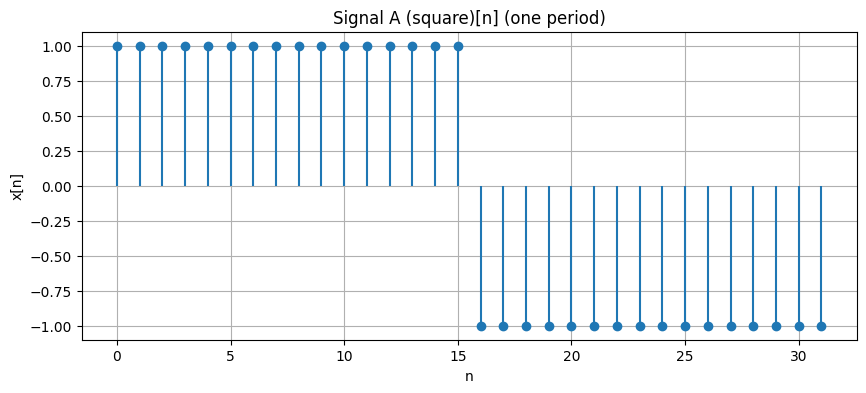

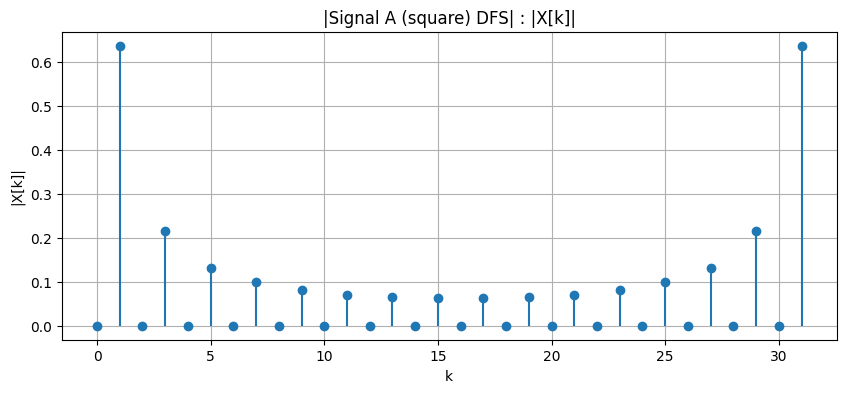

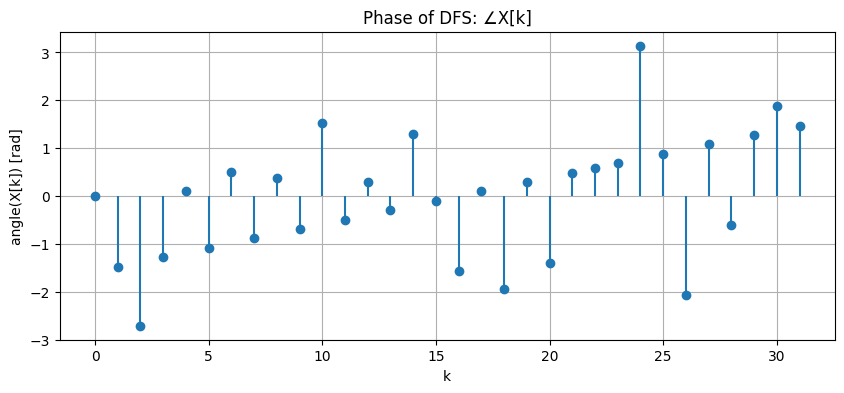

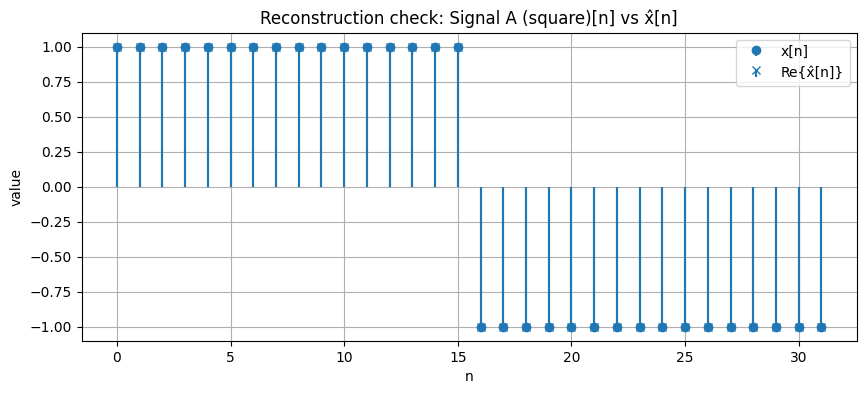

Signal B (triangle): N=48, RMSE=6.314493e-15


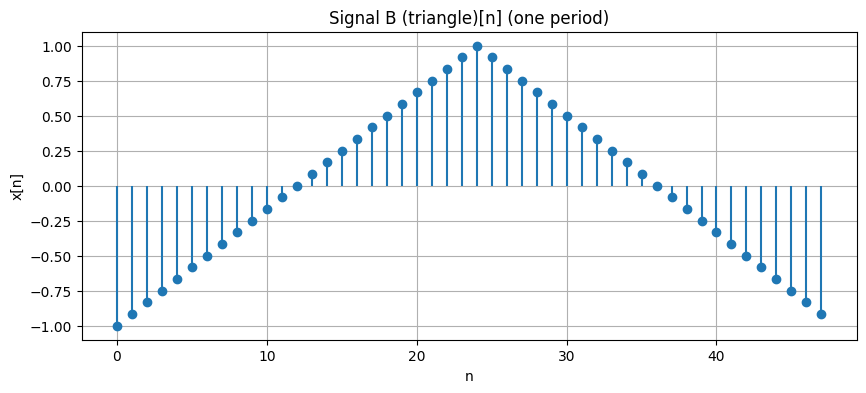

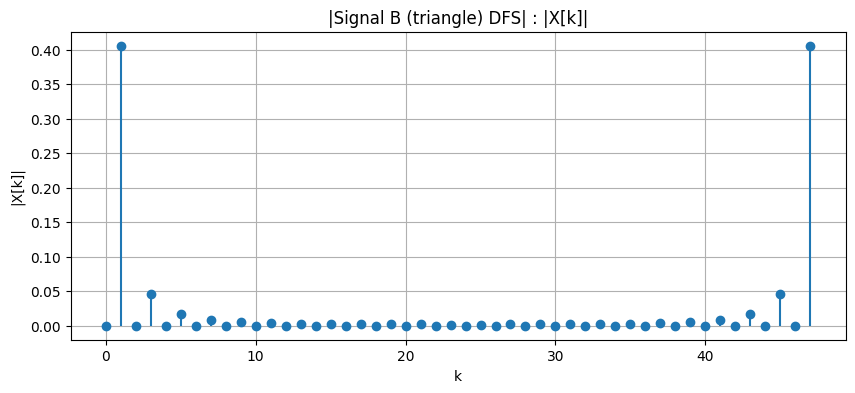

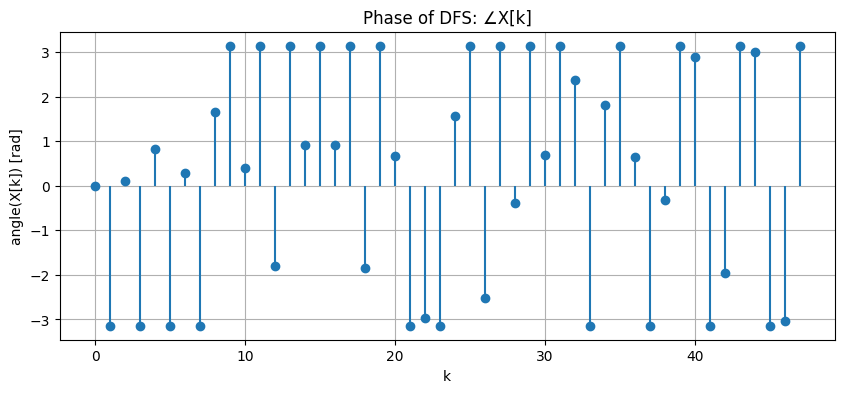

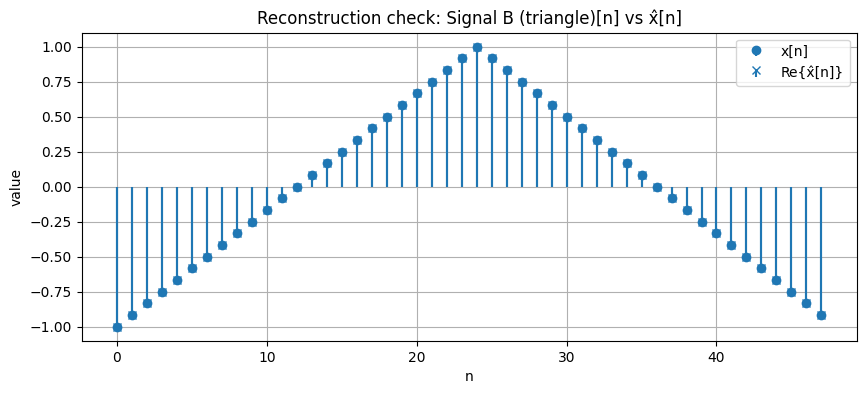

Signal C (sum of sinusoids): N=64, RMSE=7.338548e-15


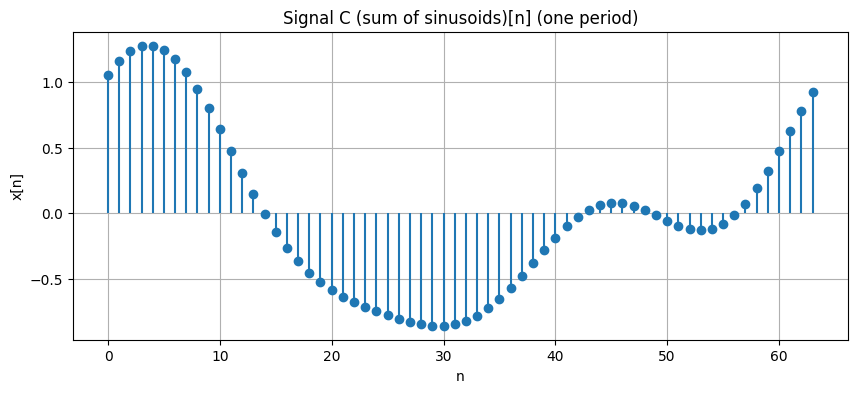

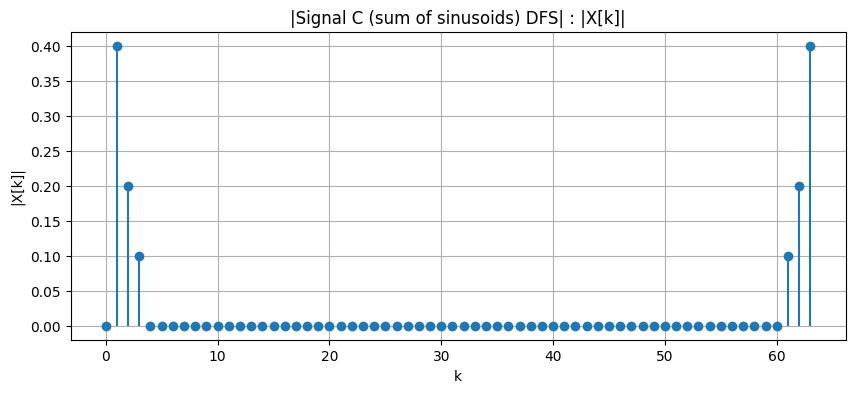

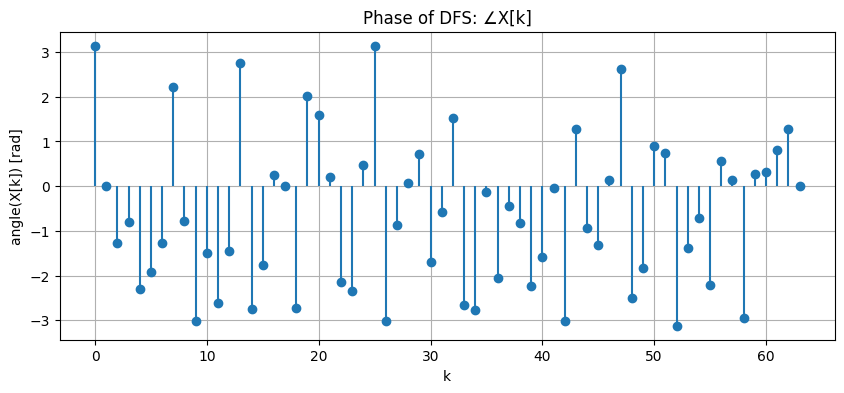

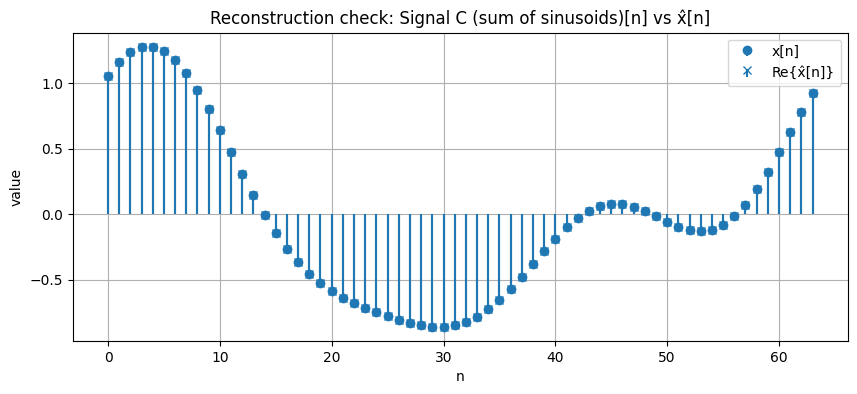

In [4]:
def analyze_signal(x, name="x"):
    """Compute DFS, reconstruct, plot, and print RMSE for one period."""
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)

    # --- DFS / IDFS ---
    X = dfs(x)
    x_hat = idfs(X)

    # --- Error ---
    e = rmse(x, x_hat)
    print(f"{name}: N={N}, RMSE={e:.6e}")

    # --- Plots: time domain ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ")
    plt.title(f"{name}[n] (one period)")
    plt.xlabel("n"); plt.ylabel("x[n]")
    plt.grid(True)
    plt.show()

    # --- Plots: magnitude spectrum ---
    k = np.arange(N)
    plt.figure()
    plt.stem(k, np.abs(X), basefmt=" ")
    plt.title(f"|{name} DFS| : |X[k]|")
    plt.xlabel("k"); plt.ylabel("|X[k]|")
    plt.grid(True)
    plt.show()

    # --- Plots: phase spectrum ---
    plt.figure()
    plt.stem(k, np.angle(X), basefmt=" ")
    plt.title(f"Phase of DFS: ∠X[k]")
    plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
    plt.grid(True)
    plt.show()

    # --- Plots: reconstruction ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ", markerfmt="o", label="x[n]")
    plt.stem(n, np.real(x_hat), basefmt=" ", markerfmt="x", label="Re{x̂[n]}")

    plt.title(f"Reconstruction check: {name}[n] vs x̂[n]")
    plt.xlabel("n"); plt.ylabel("value")
    plt.grid(True)
    plt.legend()
    plt.show()

    return X, x_hat


# === TODO 4: Run analysis for A, B, C ===
# Uncomment when you have implemented dfs/idfs and signals.

XA, xA_hat = analyze_signal(xA, name="Signal A (square)")
XB, xB_hat = analyze_signal(xB, name="Signal B (triangle)")
XC, xC_hat = analyze_signal(xC, name="Signal C (sum of sinusoids)")


## Short reflection (write your answers here)

For each signal:

- How many coefficients (roughly) are “dominant” in magnitude?
- Does the phase look structured or noisy? Why?
- If you keep only the largest M coefficients (optional extension), what happens in reconstruction?

Señal 1. Señal Cuadrada
Para dicha señal se puede observar que los armónicos impares son los más dominantes, en espcial el 1. Los coeficientes se ven estructurados porque la señal es periodica y simetrica. Sigue reconstruyendose una señal cuadrada pero con transiciones mas suaves.

Señal 2. Señal Triangular.
En ella se pudo observar que los coeficientes más significativos con el 1, 3 y 5. Tambíen la fase está bien estructurada al tener una forma regular y simétrica. Si se conservan solo los armónicos principales, la señal se pude reconstruir bastante bien, ya que podemos ver que su energía se concentra en pocos armónicos.

Señal 3. Señal Senoidal
Se puede observar que son 3 coeficientes dominantes que corresponden a las frecuencias de cada una de las señales senoidales que la construyen. Tiene una estructura bien específica porque cada senoidal tiene una fase correspondiente. Por último solo se conservan los 3 coeficientes principales, la señal se puede reconstruir de casi manera perfecta.
